# Project: Model-Observation synthesis for the carbon cycle response to Marine Heat Waves in the NE Subarctic Pacific

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dateutil.parser import parse
import PyCO2SYS as pyco2

In [6]:
# data files are available at https://github.com/takaito1/MITgcm_GoA/blob/main/data_analysis

In [28]:
def nancov(D):
    tmp =np.sum(D,axis=0)
    isgood = np.isnan(tmp)==False
    c = np.cov(D[:,isgood])
    r = np.corrcoef(D[:,isgood])
    return c, r

In [18]:
def eval_bias(obs, model):
    tmp = obs + model
    isgood = np.isnan(tmp)==False
    tmp = np.corrcoef(obs[isgood],model[isgood])
    r = tmp[0,1]
    bias = np.mean(model[isgood]) - np.mean(obs[isgood])
    return np.mean(model[isgood]), np.mean(obs[isgood]), bias, r

In [19]:
ds_obs = xr.open_dataset('monthly_OSP_CO2_mooring.nc')
ds_mod = xr.open_dataset('Abe_etal_BG_OSP_monthly_surface.nc')

In [20]:
# align time axis
ds_obs=ds_obs.interp(time=ds_mod.time)

In [21]:
# pCO2 comparison
time = ds_mod.time.to_numpy()
pco2_mooring = ds_obs['pCO2 SW (sat) (uatm)'].to_numpy()
SST_mooring = ds_obs['SST (C)'].to_numpy()
SSS_mooring = ds_obs['Salinity'].to_numpy()
pco2_model = ds_mod.pCO2.to_numpy()
SST_model = ds_mod.THETA.to_numpy()
SSS_model = ds_mod.SALT.to_numpy()
DIC_model = ds_mod.DIC.to_numpy()*1e6/1025
Alk_model = ds_mod.Alk.to_numpy()*1e6/1025

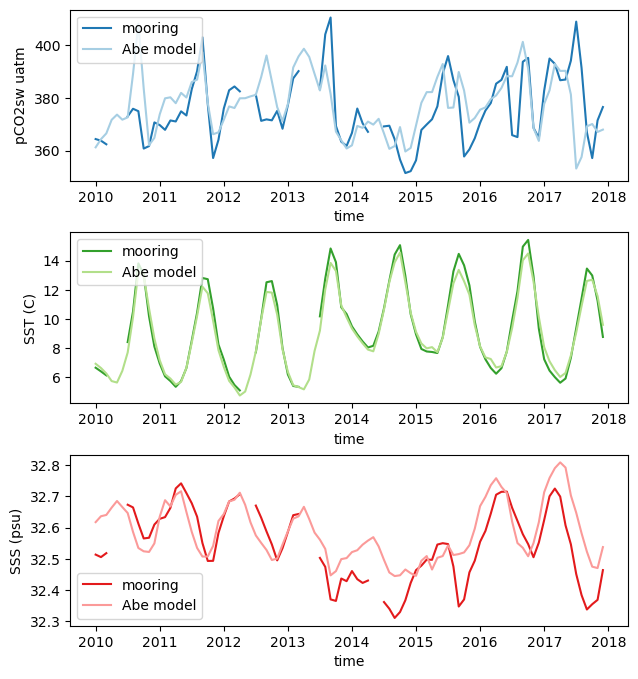

In [22]:
fig=plt.figure(figsize=(7.2,8))
cmap=plt.get_cmap('Paired')
#
ax=fig.subplots(3,1)
plt.subplots_adjust(hspace=.3)
#
ax[0].plot(time,pco2_mooring,color=cmap(1),label='mooring')
ax[0].plot(time,pco2_model,color=cmap(0),label='Abe model')
#ax[0].plot(time_model,pco2_model0,'--',color=cmap(0),label='Abe calc')
ax[0].set_xlabel('time')
ax[0].set_ylabel('pCO2sw uatm')
ax[0].legend()
#
ax[1].plot(time,SST_mooring,color=cmap(3),label='mooring')
ax[1].plot(time,SST_model,color=cmap(2),label='Abe model')
ax[1].set_xlabel('time')
ax[1].set_ylabel('SST (C)')
ax[1].legend()
#
ax[2].plot(time,SSS_mooring,color=cmap(5),label='mooring')
ax[2].plot(time,SSS_model,color=cmap(4),label='Abe model')
ax[2].set_xlabel('time')
ax[2].set_ylabel('SSS (psu)')
ax[2].legend()
#

## 1. Filling data gaps
- The data gap is relatively large.
- Interpolation: we may use polynomial fit to smoothly fill data gaps, but this may not work well for large gaps. 
- Seasonal decomposition: we may separate data into seasonal and inter-annual components, and use known seasonal cycle to fill data gaps (interpolating inter-annual variability only)
- Model prior: Abe model is highly skillful (r=0.8+) in predicting T and S and is moderately skilled (r=0.5) in pCO2 without any data gaps. Use this as a prior estimate, and combine model output and the mooored observation to come up with a best estimate of the pCO2 time series data

## 2. Estimating DIC and Alkalinity time series
- Mooring data does not include DIC and Alkalinity observations
- These variables are linked to pCO2 observations through carbonate chemistry (we can use PyCO2SYS package)
- $\delta pCO_2 = \alpha_T \delta T + \alpha_S \delta S + \alpha_C \delta DIC + \alpha_A \delta Alk$
- The question: Given observed T, S, and pCO2 (gap filled), obtain the best estimates of DIC and Alkalinity using our knowledge of carbonate chemistry ($\alpha_i$)
- Abe model includes all above variables in the output
- Model prior: Combine model output and existing mooored observation (T, S, pCO2) to come up with a best estimate of the DIC and Alkalinity time series data
- Once complete, you can validate your DIC and Alkalinity reconstructions against the mooring's pH data, and DIC and Alkalinity data from World Ocean Database

## 3. Final product
- Based on the modeled and observed time series of T, S, pCO2, Alk and DIC, explain what caused the pCO2 excursions during marine heat waves of 2014, 2019 and 2023?